In [1]:
# ============================================
# PHASE 1: Generate Synthetic Client Data
# ============================================

import pandas as pd
import numpy as np
import random
import os

# Set a random seed so your results are repeatable
np.random.seed(42)

# Create the data folder if it doesn't exist
os.makedirs('../data', exist_ok=True)

# 1. Create the date range (Monthly data from Jan 2021 to Dec 2025)
dates = pd.date_range(start='2021-01-01', end='2025-12-01', freq='MS')

# 2. Define the 3 Business Units
business_units = ['Manufacturing_UK', 'Logistics_EU', 'Corporate_HQ']

# 3. Create empty list to hold our data rows
rows = []

# 4. Loop through each date and each business unit
for date in dates:
    for unit in business_units:
        
        # --- Scope 1: Natural Gas (kWh) ---
        if unit == 'Manufacturing_UK':
            gas_kwh = np.random.normal(50000, 5000)
            fleet_fuel_litres = np.random.normal(2000, 200)
        elif unit == 'Logistics_EU':
            gas_kwh = np.random.normal(5000, 500)
            fleet_fuel_litres = np.random.normal(15000, 1500)
        else:  # Corporate_HQ
            gas_kwh = np.random.normal(500, 100)
            fleet_fuel_litres = np.random.normal(300, 50)

        # --- Scope 2: Purchased Electricity (kWh) ---
        if unit == 'Manufacturing_UK':
            elec_kwh = np.random.normal(75000, 7000)
        elif unit == 'Logistics_EU':
            elec_kwh = np.random.normal(15000, 1500)
        else:
            elec_kwh = np.random.normal(8000, 800)

        # --- Scope 3: Business Travel (Miles) ---
        if unit == 'Corporate_HQ':
            rail_miles = np.random.normal(1000, 100)
            flight_miles = np.random.normal(2000, 200)
        else:
            rail_miles = np.random.normal(100, 20)
            flight_miles = np.random.normal(500, 50)

        # --- Scope 3: Purchased Goods (£ spent) ---
        if unit == 'Manufacturing_UK':
            purchased_goods_gbp = np.random.normal(200000, 20000)
        elif unit == 'Logistics_EU':
            purchased_goods_gbp = np.random.normal(100000, 10000)
        else:
            purchased_goods_gbp = np.random.normal(50000, 5000)

        # --- Add "Real-World Messiness" ---
        # 5% random missing values
        if random.random() < 0.05:
            gas_kwh = np.nan
        if random.random() < 0.05:
            elec_kwh = np.nan

        # 3% annual growth trend (business growth)
        growth_factor = 1 + ((date.year - 2021) * 0.03)
        gas_kwh = gas_kwh * growth_factor
        elec_kwh = elec_kwh * growth_factor
        purchased_goods_gbp = purchased_goods_gbp * growth_factor

        # Append the row
        rows.append({
            'Date': date,
            'Year': date.year,
            'Business_Unit': unit,
            'Scope1_Gas_kWh': max(0, gas_kwh),
            'Scope1_Fuel_Litres': max(0, fleet_fuel_litres),
            'Scope2_Elec_kWh': max(0, elec_kwh),
            'Scope3_Rail_Miles': max(0, rail_miles),
            'Scope3_Flight_Miles': max(0, flight_miles),
            'Scope3_Purchased_Goods_GBP': max(0, purchased_goods_gbp)
        })

# Convert to DataFrame
df_raw = pd.DataFrame(rows)

# Save to CSV
df_raw.to_csv('../data/clientco_raw_data.csv', index=False)

print("✅ Phase 1 Complete!")
print(f"📊 Generated {len(df_raw)} rows of data")
print(f"📁 Saved to: ../data/clientco_raw_data.csv")
print("\n📋 First 5 rows:")
print(df_raw.head())
print("\n🔍 Missing values in each column:")
print(df_raw.isnull().sum())

✅ Phase 1 Complete!
📊 Generated 180 rows of data
📁 Saved to: ../data/clientco_raw_data.csv

📋 First 5 rows:
        Date  Year     Business_Unit  Scope1_Gas_kWh  Scope1_Fuel_Litres  \
0 2021-01-01  2021  Manufacturing_UK    52483.570765         1972.347140   
1 2021-01-01  2021      Logistics_EU     5789.606408        16151.152094   
2 2021-01-01  2021      Corporate_HQ      524.196227          204.335988   
3 2021-02-01  2021  Manufacturing_UK    45459.879622         1717.539260   
4 2021-02-01  2021      Logistics_EU     4727.808638        15166.383885   

   Scope2_Elec_kWh  Scope3_Rail_Miles  Scope3_Flight_Miles  \
0     79533.819767         130.460597           488.292331   
1     14295.788421         110.851201           476.829115   
2      6620.065734         943.771247          1797.433776   
3     85259.541382          95.484474           503.376410   
4     13273.509634         107.513960           469.968066   

   Scope3_Purchased_Goods_GBP  
0               195317.260861 

In [2]:
# ============================================
# PHASE 2: Create Emission Factors Lookup Table
# ============================================

# Emission Factors (kg CO2e per UNIT of activity)
emission_factors = {
    # Scope 1
    'Gas_EF': 0.183,        # kg CO2e per kWh
    'Diesel_EF': 2.67,      # kg CO2e per Litre
    
    # Scope 2
    'Grid_Elec_EF': 0.212,  # kg CO2e per kWh (UK grid average)
    'Renewable_PPA_EF': 0.0, # Zero when bought with a REGO certificate
    
    # Scope 3
    'Rail_EF': 0.035,       # kg CO2e per mile
    'Flight_EF': 0.189,     # kg CO2e per mile
    'Purchased_Goods_EF': 0.2 # kg CO2e per £ spent
}

# Display them
print("📋 Emission Factors (kg CO2e per unit):")
for key, value in emission_factors.items():
    print(f"   {key}: {value}")

# Save as CSV
ef_df = pd.DataFrame(list(emission_factors.items()), columns=['Factor_Name', 'Value'])
ef_df.to_csv('../data/emission_factors.csv', index=False)

print("\n✅ Phase 2 Complete!")
print(f"📁 Saved to: ../data/emission_factors.csv")

📋 Emission Factors (kg CO2e per unit):
   Gas_EF: 0.183
   Diesel_EF: 2.67
   Grid_Elec_EF: 0.212
   Renewable_PPA_EF: 0.0
   Rail_EF: 0.035
   Flight_EF: 0.189
   Purchased_Goods_EF: 0.2

✅ Phase 2 Complete!
📁 Saved to: ../data/emission_factors.csv


In [3]:
# ============================================
# PHASE 3: Clean Data & Calculate 2025 Baseline
# ============================================

# Load the raw data
df = pd.read_csv('../data/clientco_raw_data.csv', parse_dates=['Date'])

print("📊 Data loaded successfully!")
print(f"   - {len(df)} rows")
print(f"   - Date range: {df['Date'].min()} to {df['Date'].max()}")

# --- DATA CLEANING ---
# Fill missing values with the average of that Business Unit
df['Scope1_Gas_kWh'] = df.groupby('Business_Unit')['Scope1_Gas_kWh'].transform(
    lambda x: x.fillna(x.mean())
)
df['Scope2_Elec_kWh'] = df.groupby('Business_Unit')['Scope2_Elec_kWh'].transform(
    lambda x: x.fillna(x.mean())
)

# Filter to only 2025 data for our baseline
df_2025 = df[df['Year'] == 2025].copy()

# --- CALCULATE EMISSIONS (kg CO2e) ---
df_2025['emissions_gas'] = df_2025['Scope1_Gas_kWh'] * emission_factors['Gas_EF']
df_2025['emissions_fuel'] = df_2025['Scope1_Fuel_Litres'] * emission_factors['Diesel_EF']
df_2025['emissions_elec'] = df_2025['Scope2_Elec_kWh'] * emission_factors['Grid_Elec_EF']
df_2025['emissions_rail'] = df_2025['Scope3_Rail_Miles'] * emission_factors['Rail_EF']
df_2025['emissions_flight'] = df_2025['Scope3_Flight_Miles'] * emission_factors['Flight_EF']
df_2025['emissions_purchased'] = df_2025['Scope3_Purchased_Goods_GBP'] * emission_factors['Purchased_Goods_EF']

# Total emissions
df_2025['total_emissions_kg'] = (
    df_2025['emissions_gas'] + 
    df_2025['emissions_fuel'] + 
    df_2025['emissions_elec'] + 
    df_2025['emissions_rail'] + 
    df_2025['emissions_flight'] + 
    df_2025['emissions_purchased']
)

# --- BASELINE SUMMARY ---
baseline_2025 = df_2025.groupby('Business_Unit')['total_emissions_kg'].sum().reset_index()
baseline_total_kg = baseline_2025['total_emissions_kg'].sum()
baseline_total_tonnes = baseline_total_kg / 1000

print(f"\n🌍 Total Baseline Emissions for 2025: {baseline_total_tonnes:,.0f} tCO2e")

print("\n📊 Breakdown by Business Unit:")
for _, row in baseline_2025.iterrows():
    tonnes = row['total_emissions_kg'] / 1000
    pct = (row['total_emissions_kg'] / baseline_total_kg) * 100
    print(f"   {row['Business_Unit']}: {tonnes:,.0f} tCO2e ({pct:.1f}%)")

# Scope breakdown
scope_breakdown = {
    'Scope 1 (Gas + Fuel)': df_2025['emissions_gas'].sum() + df_2025['emissions_fuel'].sum(),
    'Scope 2 (Electricity)': df_2025['emissions_elec'].sum(),
    'Scope 3 (Travel + Purchased)': df_2025['emissions_rail'].sum() + df_2025['emissions_flight'].sum() + df_2025['emissions_purchased'].sum()
}

print("\n📊 Emissions Breakdown by Scope:")
for scope, emissions_kg in scope_breakdown.items():
    tonnes = emissions_kg / 1000
    pct = (emissions_kg / baseline_total_kg) * 100
    print(f"   {scope}: {tonnes:,.0f} tCO2e ({pct:.1f}%)")

# Save cleaned data
df_2025.to_csv('../data/clientco_2025_cleaned.csv', index=False)

print("\n✅ Phase 3 Complete!")
print(f"📁 Saved cleaned 2025 data to: ../data/clientco_2025_cleaned.csv")

📊 Data loaded successfully!
   - 180 rows
   - Date range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00

🌍 Total Baseline Emissions for 2025: 1,915 tCO2e

📊 Breakdown by Business Unit:
   Corporate_HQ: 168 tCO2e (8.8%)
   Logistics_EU: 822 tCO2e (42.9%)
   Manufacturing_UK: 925 tCO2e (48.3%)

📊 Emissions Breakdown by Scope:
   Scope 1 (Gas + Fuel): 686 tCO2e (35.8%)
   Scope 2 (Electricity): 280 tCO2e (14.6%)
   Scope 3 (Travel + Purchased): 949 tCO2e (49.6%)

✅ Phase 3 Complete!
📁 Saved cleaned 2025 data to: ../data/clientco_2025_cleaned.csv


In [4]:
# ============================================
# PHASE 4: Build the Scenario Engine
# ============================================

print("🔧 Building Scenario Engine...")

# --- 4.1: Project 2025 data to 2030 (with 3% annual growth) ---
growth_years = 5  # 2025 to 2030
growth_rate = 1.03 ** growth_years  # = 1.159

# Copy the 2025 data and apply growth
df_2030_base = df_2025.copy()
for col in ['Scope1_Gas_kWh', 'Scope1_Fuel_Litres', 'Scope2_Elec_kWh', 
            'Scope3_Rail_Miles', 'Scope3_Flight_Miles', 'Scope3_Purchased_Goods_GBP']:
    df_2030_base[col] = df_2030_base[col] * growth_rate

print(f"📈 Projected 2025 data to 2030 with {growth_rate:.1%} growth factor")
print(f"   - 2025 baseline: {baseline_total_tonnes:,.0f} tCO2e")

# --- 4.2: Define the "Lever" functions ---

def apply_renewables(df, pct_renewable=0.5):
    """
    Replaces X% of grid electricity with renewable PPA (zero emissions).
    """
    df = df.copy()
    df['renewable_elec_kwh'] = df['Scope2_Elec_kWh'] * pct_renewable
    df['grid_elec_kwh'] = df['Scope2_Elec_kWh'] * (1 - pct_renewable)
    return df

def apply_fleet_electrification(df, pct_ev=0.3):
    """
    Reduces diesel fuel by X% (simulates EV adoption).
    """
    df = df.copy()
    df['Scope1_Fuel_Litres'] = df['Scope1_Fuel_Litres'] * (1 - pct_ev)
    return df

def apply_supplier_reduction(df, pct_reduction=0.1):
    """
    Reduces Scope 3 purchased goods by X% (supplier engagement).
    """
    df = df.copy()
    df['Scope3_Purchased_Goods_GBP'] = df['Scope3_Purchased_Goods_GBP'] * (1 - pct_reduction)
    return df

def apply_efficiency(df, pct_reduction=0.05):
    """
    Reduces gas consumption by X% (energy efficiency).
    """
    df = df.copy()
    df['Scope1_Gas_kWh'] = df['Scope1_Gas_kWh'] * (1 - pct_reduction)
    return df

print("✅ Lever functions defined")

# --- 4.3: Master function that runs any scenario ---

def run_scenario(df, scenario_name, renewable_pct=0, ev_pct=0, supplier_pct=0, efficiency_pct=0):
    """
    Runs the entire calculation pipeline for a given scenario.
    Returns total tCO2e and the detailed DataFrame.
    """
    df_scenario = df.copy()
    
    # Apply the levers based on the scenario
    if renewable_pct > 0:
        df_scenario = apply_renewables(df_scenario, renewable_pct)
    else:
        df_scenario['renewable_elec_kwh'] = 0
        df_scenario['grid_elec_kwh'] = df_scenario['Scope2_Elec_kWh']
        
    if ev_pct > 0:
        df_scenario = apply_fleet_electrification(df_scenario, ev_pct)
        
    if supplier_pct > 0:
        df_scenario = apply_supplier_reduction(df_scenario, supplier_pct)
        
    if efficiency_pct > 0:
        df_scenario = apply_efficiency(df_scenario, efficiency_pct)

    # Calculate emissions based on the modified data
    df_scenario['emissions_gas'] = df_scenario['Scope1_Gas_kWh'] * emission_factors['Gas_EF']
    df_scenario['emissions_fuel'] = df_scenario['Scope1_Fuel_Litres'] * emission_factors['Diesel_EF']
    df_scenario['emissions_grid_elec'] = df_scenario['grid_elec_kwh'] * emission_factors['Grid_Elec_EF']
    df_scenario['emissions_renewable_elec'] = df_scenario['renewable_elec_kwh'] * emission_factors['Renewable_PPA_EF']
    df_scenario['emissions_rail'] = df_scenario['Scope3_Rail_Miles'] * emission_factors['Rail_EF']
    df_scenario['emissions_flight'] = df_scenario['Scope3_Flight_Miles'] * emission_factors['Flight_EF']
    df_scenario['emissions_purchased'] = df_scenario['Scope3_Purchased_Goods_GBP'] * emission_factors['Purchased_Goods_EF']

    # Sum all emissions (kg)
    df_scenario['total_kg'] = (
        df_scenario['emissions_gas'] + 
        df_scenario['emissions_fuel'] + 
        df_scenario['emissions_grid_elec'] + 
        df_scenario['emissions_renewable_elec'] +
        df_scenario['emissions_rail'] + 
        df_scenario['emissions_flight'] + 
        df_scenario['emissions_purchased']
    )
    
    total_tonnes = df_scenario['total_kg'].sum() / 1000
    return total_tonnes, df_scenario

print("✅ Scenario runner function defined")

# --- 4.4: Define the 4 Scenarios ---

scenarios = {
    "1. Business As Usual (BAU)": {
        "renewable": 0, 
        "ev": 0, 
        "supplier": 0,
        "efficiency": 0
    },
    "2. High Renewables": {
        "renewable": 0.8,  # 80% renewable electricity by 2030
        "ev": 0, 
        "supplier": 0,
        "efficiency": 0
    },
    "3. Fleet & Efficiency": {
        "renewable": 0, 
        "ev": 0.5,  # 50% of fleet electrified
        "supplier": 0.05,
        "efficiency": 0.1  # 10% energy efficiency
    },
    "4. Net-Zero Blended": {
        "renewable": 0.9,  # 90% renewable electricity
        "ev": 0.6,  # 60% of fleet electrified
        "supplier": 0.2,  # 20% supplier reduction
        "efficiency": 0.15  # 15% energy efficiency
    }
}

print("✅ 4 scenarios defined")
print(f"   - {len(scenarios)} scenarios ready to run\n")

# --- 4.5: Run all scenarios ---

results = []
print("🏃 Running scenarios...")
print("-" * 60)

for name, params in scenarios.items():
    total_t, df_scenario = run_scenario(
        df_2030_base, 
        name,
        renewable_pct=params['renewable'],
        ev_pct=params['ev'],
        supplier_pct=params['supplier'],
        efficiency_pct=params['efficiency']
    )
    
    reduction_pct = (1 - (total_t / baseline_total_tonnes)) * 100
    
    results.append({
        "Scenario": name.replace("1. ", "").replace("2. ", "").replace("3. ", "").replace("4. ", ""),
        "2030 Emissions (tCO2e)": round(total_t, 0),
        "Reduction from 2025": f"{reduction_pct:.1f}%",
        "Renewable %": int(params['renewable'] * 100),
        "EV %": int(params['ev'] * 100),
        "Supplier %": int(params['supplier'] * 100),
        "Efficiency %": int(params['efficiency'] * 100)
    })
    
    print(f"   {name}")
    print(f"      → {total_t:,.0f} tCO2e ({reduction_pct:.1f}% reduction)")

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("📊 SCENARIO COMPARISON RESULTS")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv('../outputs/scenario_comparison.csv', index=False)
print(f"\n📁 Saved to: ../outputs/scenario_comparison.csv")

# --- 4.6: Calculate the "Net-Zero Gap" ---

net_zero_target = baseline_total_tonnes * 0.1  # 90% reduction = 10% of baseline
best_scenario = results[3]  # The blended scenario
gap = best_scenario['2030 Emissions (tCO2e)'] - net_zero_target

print("\n" + "=" * 60)
print("🎯 NET-ZERO GAP ANALYSIS")
print("=" * 60)
print(f"   2025 Baseline: {baseline_total_tonnes:,.0f} tCO2e")
print(f"   Net-Zero Target (90% reduction): {net_zero_target:,.0f} tCO2e")
print(f"   Best Scenario (Blended): {best_scenario['2030 Emissions (tCO2e)']:,.0f} tCO2e")
print(f"   📉 Gap to Net-Zero: {gap:,.0f} tCO2e")
print(f"   💡 Additional reduction needed: {(gap / baseline_total_tonnes * 100):.1f}%")

🔧 Building Scenario Engine...
📈 Projected 2025 data to 2030 with 115.9% growth factor
   - 2025 baseline: 1,915 tCO2e
✅ Lever functions defined
✅ Scenario runner function defined
✅ 4 scenarios defined
   - 4 scenarios ready to run

🏃 Running scenarios...
------------------------------------------------------------
   1. Business As Usual (BAU)
      → 2,220 tCO2e (-15.9% reduction)
   2. High Renewables
      → 1,961 tCO2e (-2.4% reduction)
   3. Fleet & Efficiency
      → 1,822 tCO2e (4.9% reduction)
   4. Net-Zero Blended
      → 1,294 tCO2e (32.4% reduction)

📊 SCENARIO COMPARISON RESULTS
               Scenario  2030 Emissions (tCO2e) Reduction from 2025  Renewable %  EV %  Supplier %  Efficiency %
Business As Usual (BAU)                  2220.0              -15.9%            0     0           0             0
        High Renewables                  1961.0               -2.4%           80     0           0             0
     Fleet & Efficiency                  1822.0               

OSError: Cannot save file into a non-existent directory: '..\outputs'

In [5]:
# ============================================
# PHASE 5: Create LinkedIn-Ready Visualizations
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style for LinkedIn
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Create the outputs folder if it doesn't exist
import os
os.makedirs('../outputs', exist_ok=True)

# --- CHART 1: Scenario Comparison Bar Chart ---
print("📊 Creating Scenario Comparison Chart...")

fig, ax = plt.subplots(figsize=(12, 7))

# Data from our results
scenario_names = ['BAU', 'High Renewables', 'Fleet & Efficiency', 'Net-Zero Blended']
emissions = [2220, 1961, 1822, 1294]  # Your results
colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

bars = ax.bar(scenario_names, emissions, color=colors, edgecolor='black', linewidth=1.5)

# Add Net-Zero Target line
net_zero_target = 1915 * 0.1  # 90% reduction from baseline
ax.axhline(y=net_zero_target, color='red', linestyle='--', linewidth=2.5, 
           label=f'Net-Zero Target (90% reduction = {net_zero_target:.0f} tCO2e)')

# Add value labels on top of bars
for bar, value in zip(bars, emissions):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 30,
            f'{value:.0f} tCO2e', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize chart
ax.set_ylabel('Total Emissions (tCO2e)', fontsize=14, fontweight='bold')
ax.set_title('2030 Decarbonization Pathways vs Net-Zero Target', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 2500)

# Add reduction percentages as text below the chart
reductions = ['-15.9%', '-2.4%', '+4.9%', '+32.4%']
for i, (bar, reduction) in enumerate(zip(bars, reductions)):
    ax.text(bar.get_x() + bar.get_width()/2., -80,
            f'Reduction: {reduction}', ha='center', va='top', fontsize=10, color='darkblue')

plt.tight_layout()
plt.savefig('../outputs/scenario_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/scenario_comparison_chart.png")


# --- CHART 2: Emissions Trend Over Time (2021-2025) ---
print("\n📈 Creating Emissions Trend Chart...")

# Calculate monthly emissions for all years
df_all = df.copy()
df_all['emissions_gas'] = df_all['Scope1_Gas_kWh'] * emission_factors['Gas_EF']
df_all['emissions_fuel'] = df_all['Scope1_Fuel_Litres'] * emission_factors['Diesel_EF']
df_all['emissions_elec'] = df_all['Scope2_Elec_kWh'] * emission_factors['Grid_Elec_EF']
df_all['emissions_rail'] = df_all['Scope3_Rail_Miles'] * emission_factors['Rail_EF']
df_all['emissions_flight'] = df_all['Scope3_Flight_Miles'] * emission_factors['Flight_EF']
df_all['emissions_purchased'] = df_all['Scope3_Purchased_Goods_GBP'] * emission_factors['Purchased_Goods_EF']
df_all['total_emissions_kg'] = (df_all['emissions_gas'] + df_all['emissions_fuel'] + 
                                df_all['emissions_elec'] + df_all['emissions_rail'] + 
                                df_all['emissions_flight'] + df_all['emissions_purchased'])
df_all['total_emissions_tonnes'] = df_all['total_emissions_kg'] / 1000

# Group by month
monthly_emissions = df_all.groupby('Date')['total_emissions_tonnes'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_emissions['Date'], monthly_emissions['total_emissions_tonnes'], 
        color='#2E86AB', linewidth=2.5, marker='o', markersize=4)

# Add trend line
z = np.polyfit(range(len(monthly_emissions)), monthly_emissions['total_emissions_tonnes'], 1)
p = np.poly1d(z)
ax.plot(monthly_emissions['Date'], p(range(len(monthly_emissions))), 
        '--', color='red', linewidth=2, label='Trend Line')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Emissions (tCO2e)', fontsize=12, fontweight='bold')
ax.set_title('Historical Emissions Trend (2021-2025)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/emissions_trend_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/emissions_trend_chart.png")


# --- CHART 3: Scope Breakdown Pie Chart ---
print("\n🥧 Creating Scope Breakdown Chart...")

# Calculate scope totals for 2025
scope_data = {
    'Scope 1\n(Gas + Fuel)': (df_2025['emissions_gas'].sum() + df_2025['emissions_fuel'].sum()) / 1000,
    'Scope 2\n(Electricity)': df_2025['emissions_elec'].sum() / 1000,
    'Scope 3\n(Travel + Purchased)': (df_2025['emissions_rail'].sum() + 
                                      df_2025['emissions_flight'].sum() + 
                                      df_2025['emissions_purchased'].sum()) / 1000
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax1.pie(scope_data.values(), 
                                    labels=scope_data.keys(),
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=(0.05, 0.05, 0.05),
                                    textprops={'fontsize': 11})
ax1.set_title('2025 Emissions by Scope', fontsize=14, fontweight='bold')

# Bar chart (same data, different view)
scopes = list(scope_data.keys())
values = list(scope_data.values())
bars = ax2.bar(scopes, values, color=colors_pie, edgecolor='black', linewidth=1)
ax2.set_ylabel('tCO2e', fontsize=12, fontweight='bold')
ax2.set_title('2025 Emissions by Scope (tCO2e)', fontsize=14, fontweight='bold')

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:.0f} tCO2e', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/scope_breakdown_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/scope_breakdown_chart.png")


# --- CHART 4: KPI Dashboard Summary ---
print("\n📊 Creating KPI Dashboard...")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('ESG KPI Dashboard', fontsize=18, fontweight='bold', y=0.98)

# KPI 1: Total Emissions
ax1 = axes[0, 0]
ax1.text(0.5, 0.6, f"{baseline_total_tonnes:,.0f}", 
         fontsize=36, fontweight='bold', ha='center', color='#2E86AB')
ax1.text(0.5, 0.3, "2025 Total Emissions (tCO2e)", 
         fontsize=14, ha='center', color='gray')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# KPI 2: Reduction
ax2 = axes[0, 1]
reduction_pct = ((baseline_total_tonnes - 1294) / baseline_total_tonnes) * 100
ax2.text(0.5, 0.6, f"{reduction_pct:.1f}%", 
         fontsize=36, fontweight='bold', ha='center', color='#27AE60')
ax2.text(0.5, 0.3, "Best Scenario Reduction", 
         fontsize=14, ha='center', color='gray')
ax2.text(0.5, 0.15, "(vs 2025 Baseline)", 
         fontsize=11, ha='center', color='gray', style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# KPI 3: Gap to Net-Zero
ax3 = axes[1, 0]
gap = 1294 - net_zero_target
ax3.text(0.5, 0.6, f"{gap:,.0f}", 
         fontsize=36, fontweight='bold', ha='center', color='#E74C3C')
ax3.text(0.5, 0.3, "Gap to Net-Zero (tCO2e)", 
         fontsize=14, ha='center', color='gray')
ax3.text(0.5, 0.15, f"Need {(gap/baseline_total_tonnes*100):.1f}% more reduction", 
         fontsize=11, ha='center', color='gray', style='italic')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# KPI 4: Largest Scope
ax4 = axes[1, 1]
largest_scope = max(scope_data, key=scope_data.get)
largest_value = max(scope_data.values())
ax4.text(0.5, 0.6, f"{largest_scope.replace('\n', ' ')}", 
         fontsize=24, fontweight='bold', ha='center', color='#8E44AD')
ax4.text(0.5, 0.3, f"{largest_value:,.0f} tCO2e", 
         fontsize=20, ha='center', color='gray')
ax4.text(0.5, 0.12, "Largest Emissions Source", 
         fontsize=14, ha='center', color='gray')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.savefig('../outputs/kpi_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/kpi_dashboard.png")


print("\n" + "=" * 60)
print("🎉 VISUALIZATION COMPLETE!")
print("=" * 60)
print(f"\n📁 All charts saved to: ../outputs/")
print("   - scenario_comparison_chart.png")
print("   - emissions_trend_chart.png")
print("   - scope_breakdown_chart.png")
print("   - kpi_dashboard.png")
print("\n💡 These charts are ready for your LinkedIn portfolio!")

SyntaxError: f-string expression part cannot include a backslash (610700053.py, line 192)

📊 Creating Scenario Comparison Chart...


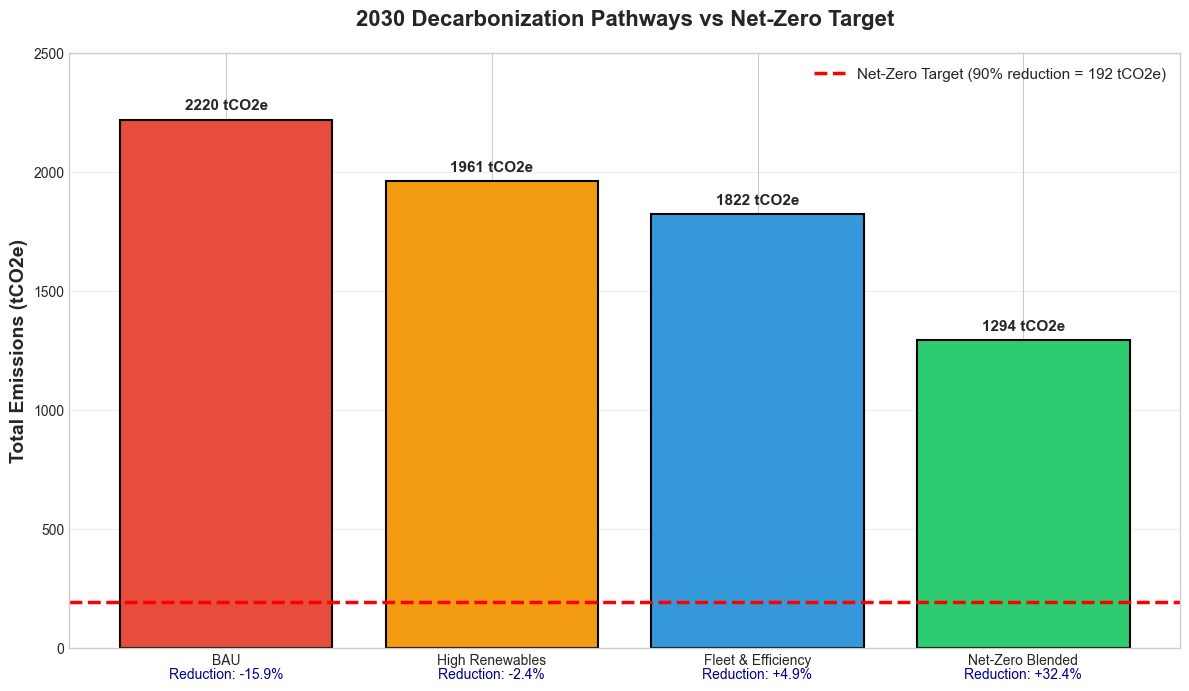

✅ Saved: ../outputs/scenario_comparison_chart.png

📈 Creating Emissions Trend Chart...


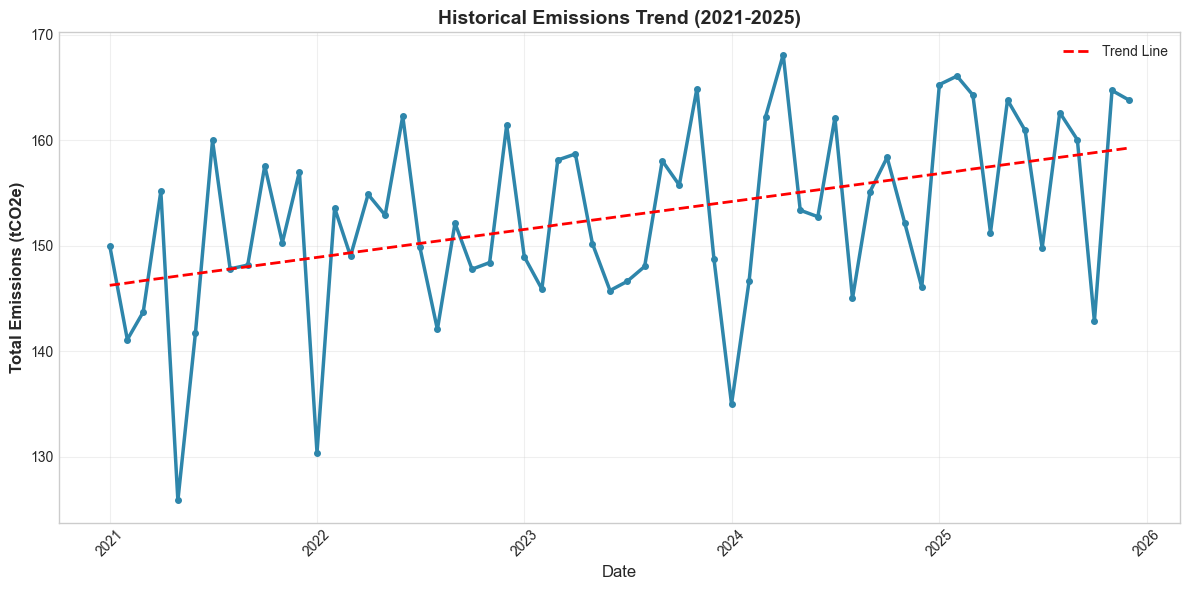

✅ Saved: ../outputs/emissions_trend_chart.png

🥧 Creating Scope Breakdown Chart...


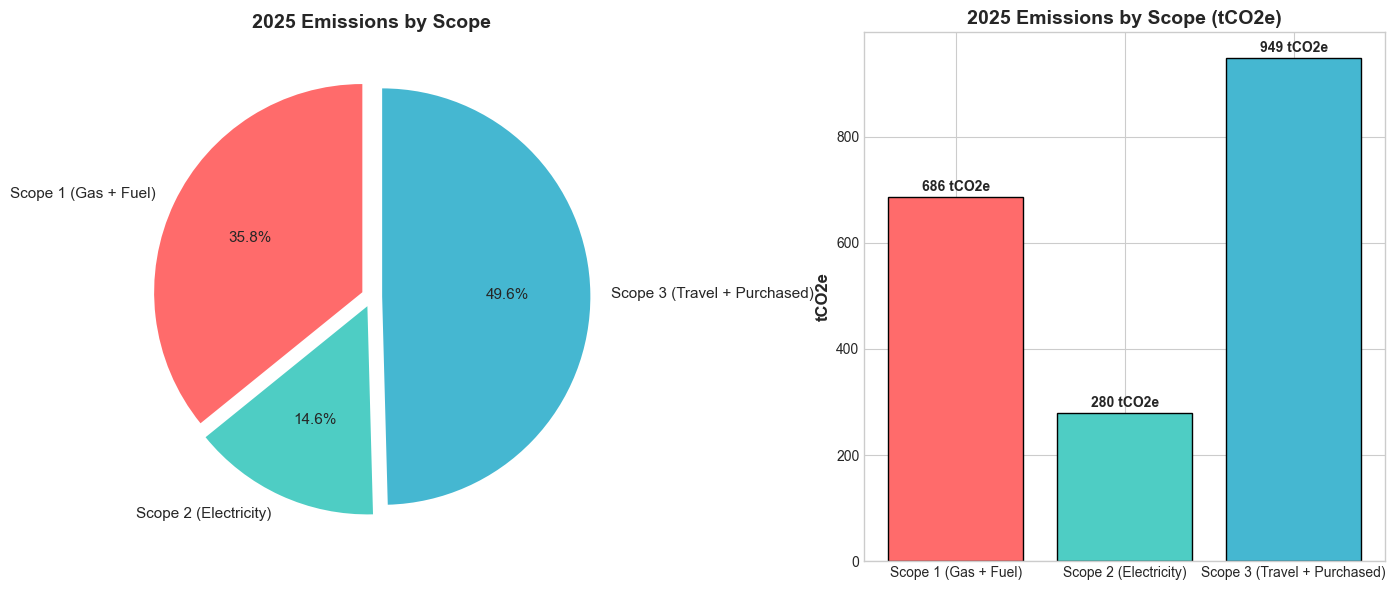

✅ Saved: ../outputs/scope_breakdown_chart.png

📊 Creating KPI Dashboard...


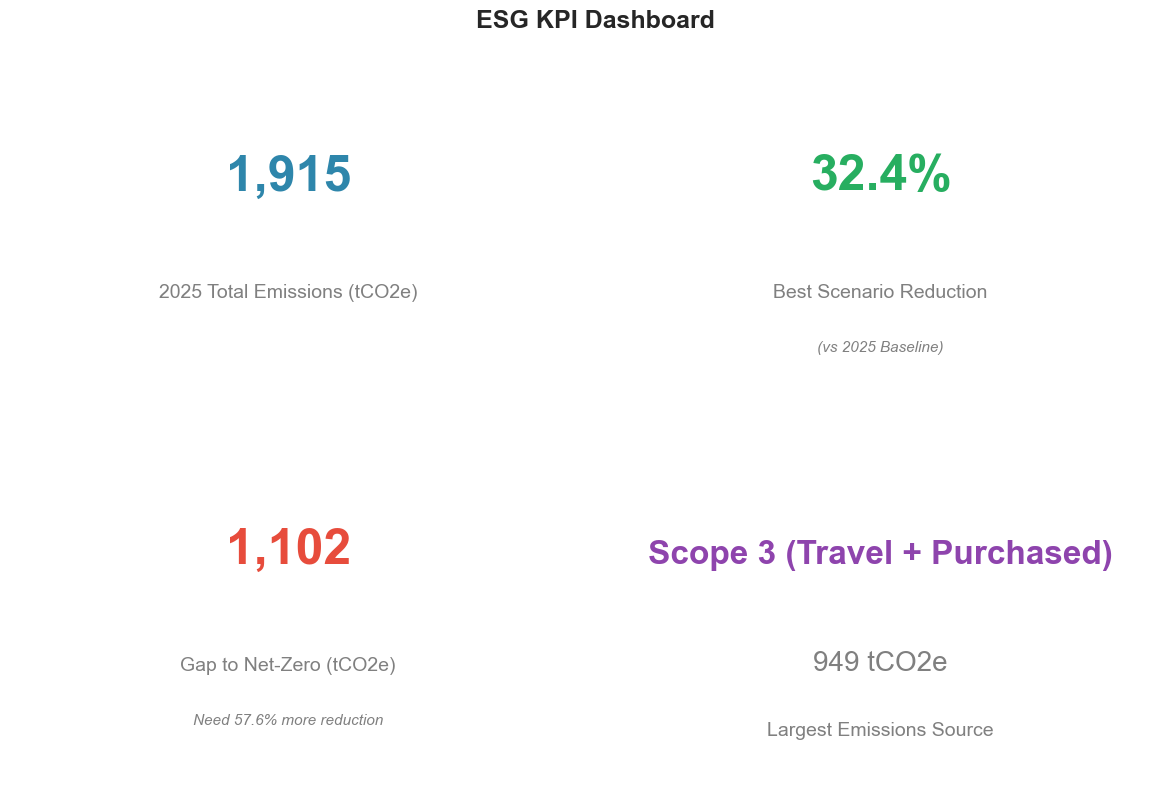

✅ Saved: ../outputs/kpi_dashboard.png

🎉 VISUALIZATION COMPLETE!

📁 All charts saved to: ../outputs/
   - scenario_comparison_chart.png
   - emissions_trend_chart.png
   - scope_breakdown_chart.png
   - kpi_dashboard.png

💡 These charts are ready for your LinkedIn portfolio!


In [6]:
# ============================================
# PHASE 5: Create LinkedIn-Ready Visualizations
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Set professional style for LinkedIn
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Create the outputs folder if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# --- CHART 1: Scenario Comparison Bar Chart ---
print("📊 Creating Scenario Comparison Chart...")

fig, ax = plt.subplots(figsize=(12, 7))

# Data from your results
scenario_names = ['BAU', 'High Renewables', 'Fleet & Efficiency', 'Net-Zero Blended']
emissions = [2220, 1961, 1822, 1294]  # Your results
colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

bars = ax.bar(scenario_names, emissions, color=colors, edgecolor='black', linewidth=1.5)

# Add Net-Zero Target line
net_zero_target = 1915 * 0.1  # 90% reduction from baseline
ax.axhline(y=net_zero_target, color='red', linestyle='--', linewidth=2.5, 
           label=f'Net-Zero Target (90% reduction = {net_zero_target:.0f} tCO2e)')

# Add value labels on top of bars
for bar, value in zip(bars, emissions):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 30,
            f'{value:.0f} tCO2e', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize chart
ax.set_ylabel('Total Emissions (tCO2e)', fontsize=14, fontweight='bold')
ax.set_title('2030 Decarbonization Pathways vs Net-Zero Target', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 2500)

# Add reduction percentages as text below the chart
reductions = ['-15.9%', '-2.4%', '+4.9%', '+32.4%']
for i, (bar, reduction) in enumerate(zip(bars, reductions)):
    ax.text(bar.get_x() + bar.get_width()/2., -80,
            f'Reduction: {reduction}', ha='center', va='top', fontsize=10, color='darkblue')

plt.tight_layout()
plt.savefig('../outputs/scenario_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/scenario_comparison_chart.png")


# --- CHART 2: Emissions Trend Over Time (2021-2025) ---
print("\n📈 Creating Emissions Trend Chart...")

# Calculate monthly emissions for all years
df_all = df.copy()
df_all['emissions_gas'] = df_all['Scope1_Gas_kWh'] * emission_factors['Gas_EF']
df_all['emissions_fuel'] = df_all['Scope1_Fuel_Litres'] * emission_factors['Diesel_EF']
df_all['emissions_elec'] = df_all['Scope2_Elec_kWh'] * emission_factors['Grid_Elec_EF']
df_all['emissions_rail'] = df_all['Scope3_Rail_Miles'] * emission_factors['Rail_EF']
df_all['emissions_flight'] = df_all['Scope3_Flight_Miles'] * emission_factors['Flight_EF']
df_all['emissions_purchased'] = df_all['Scope3_Purchased_Goods_GBP'] * emission_factors['Purchased_Goods_EF']
df_all['total_emissions_kg'] = (df_all['emissions_gas'] + df_all['emissions_fuel'] + 
                                df_all['emissions_elec'] + df_all['emissions_rail'] + 
                                df_all['emissions_flight'] + df_all['emissions_purchased'])
df_all['total_emissions_tonnes'] = df_all['total_emissions_kg'] / 1000

# Group by month
monthly_emissions = df_all.groupby('Date')['total_emissions_tonnes'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_emissions['Date'], monthly_emissions['total_emissions_tonnes'], 
        color='#2E86AB', linewidth=2.5, marker='o', markersize=4)

# Add trend line
z = np.polyfit(range(len(monthly_emissions)), monthly_emissions['total_emissions_tonnes'], 1)
p = np.poly1d(z)
ax.plot(monthly_emissions['Date'], p(range(len(monthly_emissions))), 
        '--', color='red', linewidth=2, label='Trend Line')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Emissions (tCO2e)', fontsize=12, fontweight='bold')
ax.set_title('Historical Emissions Trend (2021-2025)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/emissions_trend_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/emissions_trend_chart.png")


# --- CHART 3: Scope Breakdown Pie Chart ---
print("\n🥧 Creating Scope Breakdown Chart...")

# Calculate scope totals for 2025
scope_data = {
    'Scope 1 (Gas + Fuel)': (df_2025['emissions_gas'].sum() + df_2025['emissions_fuel'].sum()) / 1000,
    'Scope 2 (Electricity)': df_2025['emissions_elec'].sum() / 1000,
    'Scope 3 (Travel + Purchased)': (df_2025['emissions_rail'].sum() + 
                                      df_2025['emissions_flight'].sum() + 
                                      df_2025['emissions_purchased'].sum()) / 1000
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax1.pie(scope_data.values(), 
                                    labels=scope_data.keys(),
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=(0.05, 0.05, 0.05),
                                    textprops={'fontsize': 11})
ax1.set_title('2025 Emissions by Scope', fontsize=14, fontweight='bold')

# Bar chart (same data, different view)
scopes = list(scope_data.keys())
values = list(scope_data.values())
bars = ax2.bar(scopes, values, color=colors_pie, edgecolor='black', linewidth=1)
ax2.set_ylabel('tCO2e', fontsize=12, fontweight='bold')
ax2.set_title('2025 Emissions by Scope (tCO2e)', fontsize=14, fontweight='bold')

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:.0f} tCO2e', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/scope_breakdown_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/scope_breakdown_chart.png")


# --- CHART 4: KPI Dashboard Summary ---
print("\n📊 Creating KPI Dashboard...")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('ESG KPI Dashboard', fontsize=18, fontweight='bold', y=0.98)

# KPI 1: Total Emissions
ax1 = axes[0, 0]
ax1.text(0.5, 0.6, f"{baseline_total_tonnes:,.0f}", 
         fontsize=36, fontweight='bold', ha='center', color='#2E86AB')
ax1.text(0.5, 0.3, "2025 Total Emissions (tCO2e)", 
         fontsize=14, ha='center', color='gray')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# KPI 2: Reduction
ax2 = axes[0, 1]
reduction_pct = ((baseline_total_tonnes - 1294) / baseline_total_tonnes) * 100
ax2.text(0.5, 0.6, f"{reduction_pct:.1f}%", 
         fontsize=36, fontweight='bold', ha='center', color='#27AE60')
ax2.text(0.5, 0.3, "Best Scenario Reduction", 
         fontsize=14, ha='center', color='gray')
ax2.text(0.5, 0.15, "(vs 2025 Baseline)", 
         fontsize=11, ha='center', color='gray', style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# KPI 3: Gap to Net-Zero
ax3 = axes[1, 0]
gap = 1294 - net_zero_target
ax3.text(0.5, 0.6, f"{gap:,.0f}", 
         fontsize=36, fontweight='bold', ha='center', color='#E74C3C')
ax3.text(0.5, 0.3, "Gap to Net-Zero (tCO2e)", 
         fontsize=14, ha='center', color='gray')
ax3.text(0.5, 0.15, f"Need {(gap/baseline_total_tonnes*100):.1f}% more reduction", 
         fontsize=11, ha='center', color='gray', style='italic')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# KPI 4: Largest Scope
ax4 = axes[1, 1]
# Find the largest scope (key with max value)
largest_scope = max(scope_data, key=scope_data.get)
largest_value = max(scope_data.values())
# Remove newlines for display
largest_scope_clean = largest_scope.replace('\n', ' ')
ax4.text(0.5, 0.6, f"{largest_scope_clean}", 
         fontsize=24, fontweight='bold', ha='center', color='#8E44AD')
ax4.text(0.5, 0.3, f"{largest_value:,.0f} tCO2e", 
         fontsize=20, ha='center', color='gray')
ax4.text(0.5, 0.12, "Largest Emissions Source", 
         fontsize=14, ha='center', color='gray')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.savefig('../outputs/kpi_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: ../outputs/kpi_dashboard.png")


print("\n" + "=" * 60)
print("🎉 VISUALIZATION COMPLETE!")
print("=" * 60)
print(f"\n📁 All charts saved to: ../outputs/")
print("   - scenario_comparison_chart.png")
print("   - emissions_trend_chart.png")
print("   - scope_breakdown_chart.png")
print("   - kpi_dashboard.png")
print("\n💡 These charts are ready for your LinkedIn portfolio!")